# Final CRC Microbiome ML Analysis

This notebook combines the stricter final-analysis workflow with exploratory figures for the write-up, including effect size, model comparison, ROC/confusion matrix, and feature importance.

In [1]:
# Cell 0 — Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance

sns.set_context("notebook")

In [2]:
# Cell 1 — Configuration and load data
from pathlib import Path
cohort_name = "Yu cohort (PRJNA389927)" 

repo_root = Path.cwd().parent
feature_path = repo_root / "data/features/targeted_feature_matrix_Yu_PRJNA389927.csv"
out_dir = repo_root / "results/Yu_PRJNA389927"
df = pd.read_csv(feature_path)

required_cols = ["sample_id", "run_accession", "label"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Keep only binary classification labels
df = df[df["label"].isin(["healthy", "cancer"])].copy()
df["y"] = df["label"].map({"healthy": 0, "cancer": 1})

print("Loaded:", feature_path)
print("Cohort:", cohort_name)
print("Shape:", df.shape)
print("Labels:")
print(df["label"].value_counts())

df.head()

Loaded: /Users/jackpapciak/Columbia/Computational_Genomics/fuso-biomarker/data/features/targeted_feature_matrix_Yu_PRJNA389927.csv
Cohort: Yu cohort (PRJNA389927)
Shape: (80, 117)
Labels:
label
healthy    40
cancer     40
Name: count, dtype: int64


,sample_id,run_accession,label,age_group,library_name,F_nucleatum_species_abundance,Fusobacterium_genus_abundance,total_bacterial_abundance,number_of_detected_species,Shannon_diversity,...,panel_Buchavirus,panel_Buchavirus_log10,panel_Buchavirus_present,panel_Streptococcus,panel_Streptococcus_log10,panel_Streptococcus_present,panel_Canhaevirus,panel_Canhaevirus_log10,panel_Canhaevirus_present,y
0,MG100104,SRR5665169,healthy,unknown,NaN,0.00000,0.00000,0.1829,193,3.238724,...,0.00036,-3.442493,1,0.00322,-2.492009,1,0.00966,-2.014978,1,0
1,MG100115,SRR5665145,healthy,unknown,NaN,0.00000,0.00083,0.1171,242,4.006315,...,0.08737,-1.058633,1,0.00000,-6.000000,0,0.08323,-1.079715,1,0
2,MG100102,SRR5665171,healthy,unknown,NaN,0.00000,0.00019,0.5339,1485,4.199210,...,0.00009,-4.040959,0,0.00127,-2.895854,1,0.00137,-2.862963,1,0
3,MG100112,SRR5665152,healthy,unknown,NaN,0.00002,0.00008,0.4746,823,2.360926,...,0.00187,-2.727926,1,0.00096,-3.017277,1,0.09969,-1.001344,1,0
4,MG100099,SRR5665104,healthy,unknown,NaN,0.00003,0.00086,0.3414,2122,4.925298,...,0.00143,-2.844360,1,0.01677,-1.775441,1,0.00265,-2.576590,1,0


In [3]:
# Cell 2 — Define feature groups

meta_cols = [
    "sample_id", "run_accession", "label", "y", "age_group", "library_name"
]
meta_cols = [c for c in meta_cols if c in df.columns]

core_feature_cols = [
    "F_nucleatum_species_abundance",
    "Fusobacterium_genus_abundance",
    "total_bacterial_abundance",
    "number_of_detected_species",
    "Shannon_diversity",
    "sequencing_depth_proxy",
]
core_feature_cols = [c for c in core_feature_cols if c in df.columns]

diversity_cols = [
    c for c in [
        "Shannon_diversity",
        "number_of_detected_species",
        "total_bacterial_abundance",
    ]
    if c in df.columns
]

# Raw panel abundance columns are detected but NOT used in modeling
panel_abundance_cols = [
    c for c in df.columns
    if c.startswith("panel_")
    and not c.endswith("_log10")
    and not c.endswith("_present")
]

# Use these for modeling
panel_log_cols = [
    c for c in df.columns
    if c.startswith("panel_") and c.endswith("_log10")
]

panel_present_cols = [
    c for c in df.columns
    if c.startswith("panel_") and c.endswith("_present")
]

# Modeling features exclude raw panel abundance columns
all_feature_cols = list(dict.fromkeys(
    core_feature_cols + panel_log_cols + panel_present_cols
))

for col in all_feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Metadata columns:", meta_cols)
print("Core features:", len(core_feature_cols))
print("Raw panel abundance features detected but excluded:", len(panel_abundance_cols))
print("Panel log features used:", len(panel_log_cols))
print("Panel presence features used:", len(panel_present_cols))
print("Diversity features:", diversity_cols)

Metadata columns: ['sample_id', 'run_accession', 'label', 'y', 'age_group', 'library_name']
Core features: 6
Raw panel abundance features detected but excluded: 35
Panel log features used: 35
Panel presence features used: 35
Diversity features: ['Shannon_diversity', 'number_of_detected_species', 'total_bacterial_abundance']


In [4]:
# Cell 3 — Feature sanity checks

feature_summary = pd.DataFrame({
    "feature": all_feature_cols,
    "missing": [df[c].isna().sum() for c in all_feature_cols],
    "n_unique": [df[c].nunique(dropna=True) for c in all_feature_cols],
    "mean": [df[c].mean() for c in all_feature_cols],
    "std": [df[c].std() for c in all_feature_cols],
})

print("Features with the least variation:")
display(feature_summary.sort_values("n_unique").head(20))

print("Top missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

Features with the least variation:


,feature,missing,n_unique,mean,std
53,panel_Bacteroides_present,0,1,1.0000,0.000000
52,panel_Parabacteroides_present,0,1,1.0000,0.000000
45,panel_Peptostreptococcus_anaerobius_present,0,1,0.0000,0.000000
5,sequencing_depth_proxy,0,1,0.0000,0.000000
69,panel_Phocaeicola_present,0,1,1.0000,0.000000
64,panel_Pseudomonas_present,0,1,1.0000,0.000000
10,panel_Peptostreptococcus_anaerobius_log10,0,1,-6.0000,0.000000
75,panel_Canhaevirus_present,0,2,0.4000,0.492989
54,panel_Carjivirus_present,0,2,0.6875,0.466437
51,panel_Blautia_present,0,2,0.9875,0.111803


Top missing values:


library_name                  80
sample_id                      0
panel_Burkholderia             0
panel_Escherichia              0
panel_Collinsella_present      0
panel_Collinsella_log10        0
panel_Collinsella              0
panel_Pseudomonas_present      0
panel_Pseudomonas_log10        0
panel_Pseudomonas              0
panel_Ruminococcus_present     0
panel_Ruminococcus_log10       0
panel_Ruminococcus             0
panel_Burkholderia_present     0
panel_Burkholderia_log10       0
dtype: int64

In [5]:
# Cell 4 — Class-level descriptive summaries

summary_cols = [c for c in [
    "sequencing_depth_proxy",
    "number_of_detected_species",
    "Shannon_diversity",
    "total_bacterial_abundance"
] if c in df.columns]

if summary_cols:
    display(df.groupby("label")[summary_cols].describe().T)
else:
    print("No summary columns found.")

label                                  cancer      healthy
sequencing_depth_proxy     count    40.000000    40.000000
                           mean      0.000000     0.000000
                           std       0.000000     0.000000
                           min       0.000000     0.000000
                           25%       0.000000     0.000000
                           50%       0.000000     0.000000
                           75%       0.000000     0.000000
                           max       0.000000     0.000000
number_of_detected_species count    40.000000    40.000000
                           mean   1338.900000  1883.650000
                           std     832.058116  1134.437499
                           min     327.000000   193.000000
                           25%     680.250000  1105.250000
                           50%     999.000000  1639.500000
                           75%    2056.000000  2464.000000
                           max    3398.000000  4361.000000
Shannon_diversity          count    40.000000    40.000000
                           mean      3.174705     3.344318
                           std       0.820289     0.789143
                           min       1.301178     1.324347
                           25%       2.635352     2.971256
                           50%       3.272407     3.495217
                           75%       3.867450     3.940254
                           max       4.537670     4.925298
total_bacterial_abundance  count    40.000000    40.000000
                           mean      0.467430     0.473480
                           std       0.255788     0.226703
                           min       0.028300     0.050200
                           25%       0.228350     0.291225
                           50%       0.515300     0.523600
                           75%       0.669325     0.646500
                           max       0.843900     0.845500

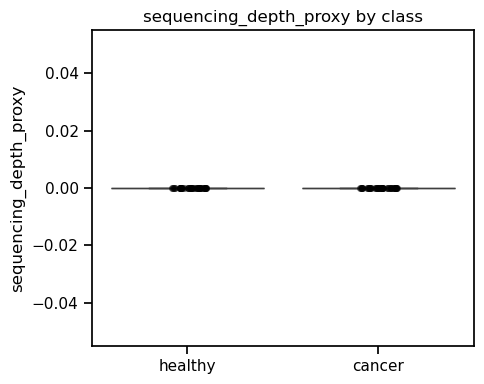

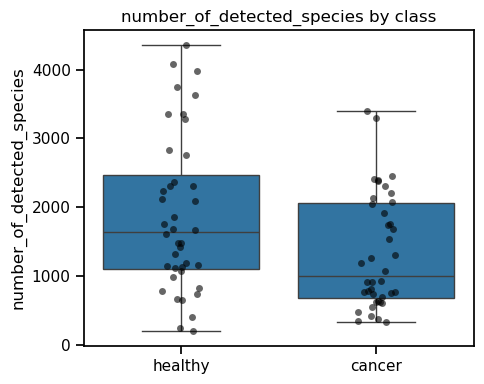

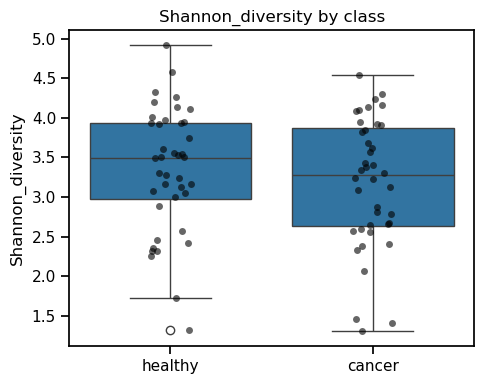

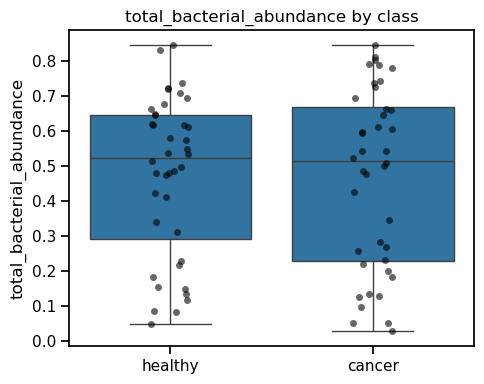

In [6]:
# Cell 5 — Plot core community metrics by class

for col in summary_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x="label", y=col)
    sns.stripplot(data=df, x="label", y=col, color="black", alpha=0.6)
    plt.title(f"{col} by class")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

In [7]:
# Cell 6 — Effect size analysis helper

# For presence features, abs_diff is a difference in prevalence.
# For log abundance features, abs_diff is a difference in mean log10 abundance.

def compute_univariate_effects(feature_cols, label="feature"):
    results = []

    for col in feature_cols:
        if col not in df.columns:
            continue

        # Skip only if completely constant across all samples
        if df[col].nunique(dropna=True) <= 1:
            continue

        g0 = df.loc[df["y"] == 0, col]  # healthy
        g1 = df.loc[df["y"] == 1, col]  # cancer

        try:
            stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
        except ValueError:
            stat, p = np.nan, np.nan

        results.append({
            "feature": col,
            "feature_source": label,
            "healthy_mean": g0.mean(),
            "cancer_mean": g1.mean(),
            "mean_diff": g1.mean() - g0.mean(),
            "abs_diff": abs(g1.mean() - g0.mean()),
            "p_value": p,
        })

    out = pd.DataFrame(results)
    if out.empty:
        return out

    return out.sort_values(["abs_diff", "p_value"], ascending=[False, True]).reset_index(drop=True)

In [8]:
# Cell 7 — Effect size: presence features

presence_effects = compute_univariate_effects(panel_present_cols, label="presence")

if presence_effects.empty:
    print("No variable presence features found.")
else:
    display(presence_effects.head(15))

,feature,feature_source,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value
0,panel_Kingevirus_present,presence,0.450,0.150,-0.300,0.300,0.003693
1,panel_Escherichia_coli_present,presence,0.900,0.700,-0.200,0.200,0.026753
2,panel_Escherichia_present,presence,0.900,0.700,-0.200,0.200,0.026753
3,panel_Buchavirus_present,presence,0.275,0.450,0.175,0.175,0.106955
4,panel_Bifidobacterium_present,presence,0.900,0.775,-0.125,0.125,0.134056
5,panel_Roseburia_intestinalis_present,presence,0.925,0.825,-0.100,0.100,0.181755
6,panel_Ruminococcus_present,presence,0.925,0.825,-0.100,0.100,0.181755
7,panel_Mediterraneibacter_present,presence,0.975,0.875,-0.100,0.100,0.093598
8,panel_Coprococcus_present,presence,0.850,0.750,-0.100,0.100,0.269558
9,panel_Anaerobutyricum_present,presence,0.800,0.725,-0.075,0.075,0.437330


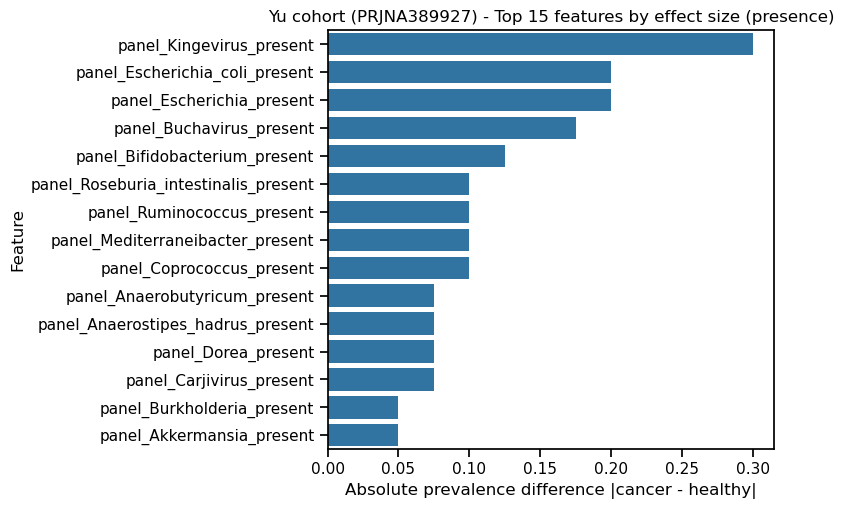

In [9]:
# Cell 8 — Plot effect size for presence features

if not presence_effects.empty:
    top_n = min(15, len(presence_effects))
    plot_df = presence_effects.head(top_n).copy()

    plt.figure(figsize=(8, max(4, 0.35 * top_n)))
    sns.barplot(data=plot_df, x="abs_diff", y="feature", orient="h")
    plt.title(f"{cohort_name} - Top {top_n} features by effect size (presence)")
    plt.xlabel("Absolute prevalence difference |cancer - healthy|")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: no variable presence features.")

In [10]:
# Cell 9 — Effect size: log10 abundance features

log_effects = compute_univariate_effects(panel_log_cols, label="log10_abundance")

if log_effects.empty:
    print("No variable log10 abundance features found.")
else:
    display(log_effects.head(15))

,feature,feature_source,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value
0,panel_Kingevirus_log10,log10_abundance,-4.212816,-5.037318,-0.824503,0.824503,0.028084
1,panel_Parabacteroides_log10,log10_abundance,-1.953547,-1.576869,0.376678,0.376678,0.115654
2,panel_Bacteroides_log10,log10_abundance,-1.446335,-1.701224,-0.254889,0.254889,0.053097
3,panel_Buchavirus_log10,log10_abundance,-4.584303,-4.362319,0.221984,0.221984,0.510523
4,panel_Romboutsia_log10,log10_abundance,-2.903157,-3.115982,-0.212825,0.212825,0.291983
5,panel_Roseburia_intestinalis_log10,log10_abundance,-2.672630,-2.884266,-0.211636,0.211636,0.413382
6,panel_Pseudomonas_log10,log10_abundance,-2.459674,-2.662813,-0.203139,0.203139,0.335918
7,panel_Burkholderia_log10,log10_abundance,-2.669445,-2.872505,-0.203060,0.203060,0.383749
8,panel_Bifidobacterium_longum_log10,log10_abundance,-3.094575,-3.291719,-0.197144,0.197144,0.657940
9,panel_Faecalibacterium_prausnitzii_log10,log10_abundance,-2.052879,-2.239817,-0.186938,0.186938,0.323974


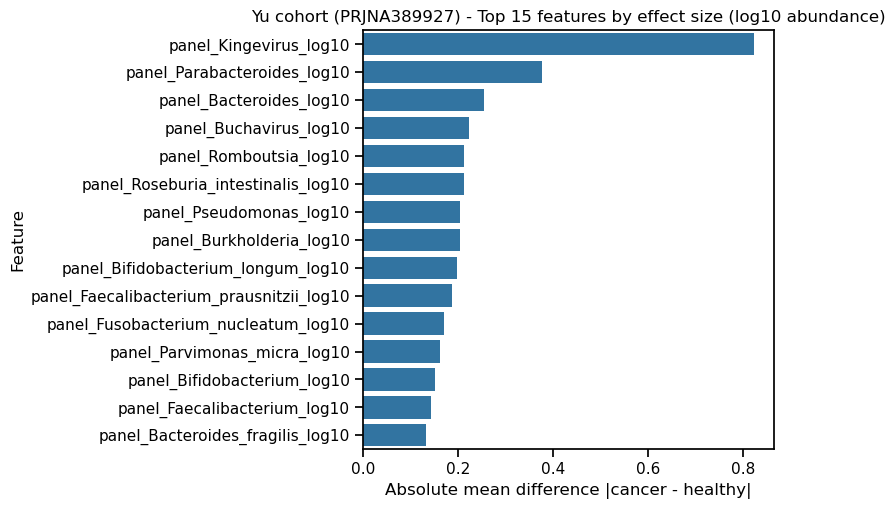

In [11]:
# Cell 10 — Plot effect size for log10 abundance features

if not log_effects.empty:
    top_n = min(15, len(log_effects))
    plot_df = log_effects.head(top_n).copy()

    plt.figure(figsize=(8, max(4, 0.35 * top_n)))
    sns.barplot(data=plot_df, x="abs_diff", y="feature", orient="h")
    plt.title(f"{cohort_name} - Top {top_n} features by effect size (log10 abundance)")
    plt.xlabel("Absolute mean difference |cancer - healthy|")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: no variable log10 abundance features.")

In [12]:
# Cell 11 — Optional: inspect direction of top effect-size features

# Positive mean_diff = higher in cancer
# Negative mean_diff = higher in healthy

if not log_effects.empty:
    display(log_effects.head(20)[[
        "feature", "healthy_mean", "cancer_mean", "mean_diff", "abs_diff", "p_value"
    ]])
elif not presence_effects.empty:
    display(presence_effects.head(20)[[
        "feature", "healthy_mean", "cancer_mean", "mean_diff", "abs_diff", "p_value"
    ]])
else:
    print("No variable panel features available for effect-size table.")

,feature,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value
0,panel_Kingevirus_log10,-4.212816,-5.037318,-0.824503,0.824503,0.028084
1,panel_Parabacteroides_log10,-1.953547,-1.576869,0.376678,0.376678,0.115654
2,panel_Bacteroides_log10,-1.446335,-1.701224,-0.254889,0.254889,0.053097
3,panel_Buchavirus_log10,-4.584303,-4.362319,0.221984,0.221984,0.510523
4,panel_Romboutsia_log10,-2.903157,-3.115982,-0.212825,0.212825,0.291983
5,panel_Roseburia_intestinalis_log10,-2.672630,-2.884266,-0.211636,0.211636,0.413382
6,panel_Pseudomonas_log10,-2.459674,-2.662813,-0.203139,0.203139,0.335918
7,panel_Burkholderia_log10,-2.669445,-2.872505,-0.203060,0.203060,0.383749
8,panel_Bifidobacterium_longum_log10,-3.094575,-3.291719,-0.197144,0.197144,0.657940
9,panel_Faecalibacterium_prausnitzii_log10,-2.052879,-2.239817,-0.186938,0.186938,0.323974


In [13]:
# Cell 12 — Define biologically fixed feature sets

# These feature sets are fixed by design, not selected from labels inside the notebook.

feature_sets = {
    "fuso_only": [
        c for c in [
            "Fusobacterium_genus_abundance",
            "F_nucleatum_species_abundance",
        ]
        if c in df.columns
    ],

    "diversity_only": diversity_cols,

    "panel_log": panel_log_cols,

    "panel_presence": panel_present_cols,

    "panel_log_plus_diversity": panel_log_cols + diversity_cols,

    "panel_presence_plus_diversity": panel_present_cols + diversity_cols,
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")

fuso_only: 2 features
diversity_only: 3 features
panel_log: 35 features
panel_presence: 35 features
panel_log_plus_diversity: 38 features
panel_presence_plus_diversity: 38 features


In [14]:
# Cell 13 — Define models

models = {
    "logistic_l2": LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=2000,
        random_state=42,
    ),

    "logistic_l1": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=2.0,
        max_iter=2000,
        random_state=42,
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
    ),
}

In [15]:
# Cell 14 — Cross-validation setup

# Main estimate: repeated stratified 5-fold CV.
# Sensitivity checks below compare other CV schemes.

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42,
)

cv_single = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [16]:
# Cell 15 — Pipeline builder

def build_pipeline(model, use_scaler=True):
    steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0))
    ]

    if use_scaler and isinstance(model, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))

    return Pipeline(steps)

In [17]:
# Cell 16 — Evaluate all feature sets and models

rows = []

for fs_name, cols in feature_sets.items():
    if len(cols) == 0:
        continue

    X = df[cols]
    y = df["y"]

    for model_name, model in models.items():
        pipe = build_pipeline(model)

        auc_scores = cross_val_score(
            pipe,
            X,
            y,
            cv=cv,
            scoring="roc_auc",
        )

        rows.append({
            "feature_set": fs_name,
            "model": model_name,
            "n_features": len(cols),
            "auc_mean": auc_scores.mean(),
            "auc_std": auc_scores.std(),
            "auc_min": auc_scores.min(),
            "auc_max": auc_scores.max(),
            "auc_2.5%": np.percentile(auc_scores, 2.5),
            "auc_97.5%": np.percentile(auc_scores, 97.5),
        })

results_df = pd.DataFrame(rows).sort_values("auc_mean", ascending=False)
results_df

/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in ve

,feature_set,model,n_features,auc_mean,auc_std,auc_min,auc_max,auc_2.5%,auc_97.5%
13,panel_log_plus_diversity,logistic_l1,38,0.651875,0.126516,0.359375,0.906250,0.397656,0.887109
12,panel_log_plus_diversity,logistic_l2,38,0.622812,0.121915,0.343750,0.875000,0.373437,0.833203
17,panel_presence_plus_diversity,random_forest,38,0.615313,0.112071,0.406250,0.875000,0.406250,0.808984
4,diversity_only,logistic_l1,3,0.609688,0.130746,0.312500,0.859375,0.366406,0.828125
3,diversity_only,logistic_l2,3,0.598437,0.131408,0.281250,0.859375,0.347266,0.821094
10,panel_presence,logistic_l1,35,0.594844,0.107063,0.359375,0.843750,0.378516,0.793359
7,panel_log,logistic_l1,35,0.582812,0.118183,0.312500,0.812500,0.333594,0.777734
16,panel_presence_plus_diversity,logistic_l1,38,0.579375,0.104248,0.359375,0.812500,0.425391,0.777734
9,panel_presence,logistic_l2,35,0.573125,0.098954,0.351562,0.781250,0.375000,0.742969
6,panel_log,logistic_l2,35,0.566875,0.122914,0.359375,0.875000,0.362891,0.814062


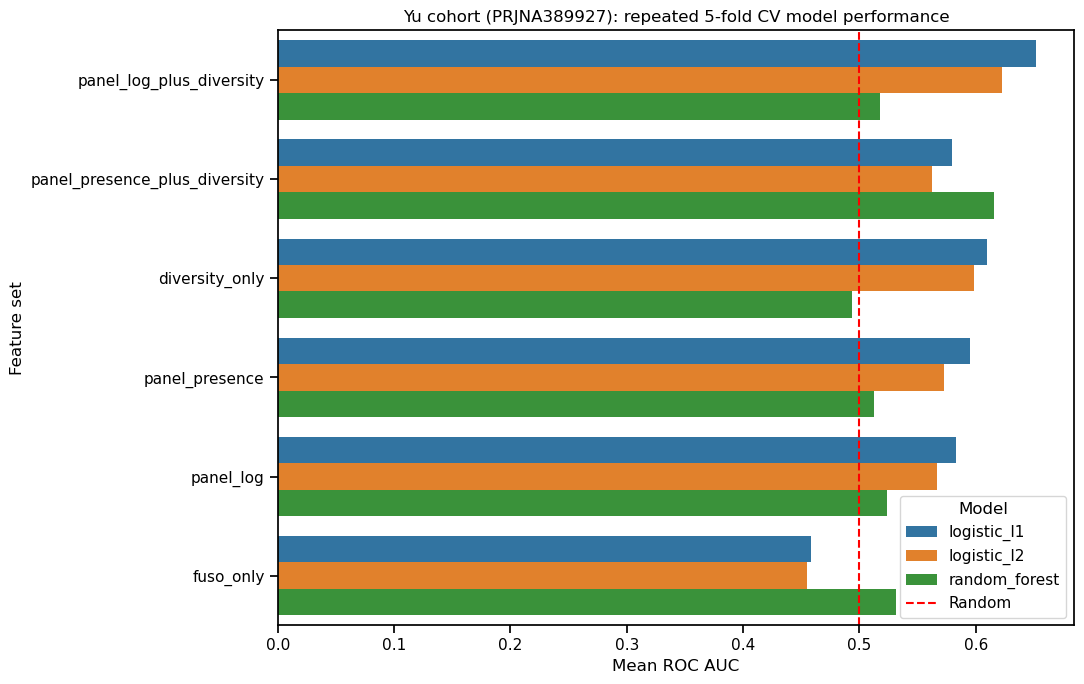

In [18]:
# Cell 17 — Plot model comparison

plot_df = results_df.copy()

feature_order = (
    plot_df.groupby("feature_set")["auc_mean"]
    .max()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=plot_df,
    x="auc_mean",
    y="feature_set",
    hue="model",
    order=feature_order,
)

plt.axvline(0.5, linestyle="--", color="red", label="Random")
plt.xlabel("Mean ROC AUC")
plt.ylabel("Feature set")
plt.title(f"{cohort_name}: repeated 5-fold CV model performance")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_rat

,feature_set,model,cv_type,auc_mean,auc_std
0,fuso_only,random_forest,single_5fold,0.531250,0.072112
1,fuso_only,random_forest,repeated_5fold,0.531875,0.125272
2,diversity_only,logistic_l1,single_5fold,0.612500,0.097026
3,diversity_only,logistic_l1,repeated_5fold,0.609688,0.130746
4,panel_log,logistic_l1,single_5fold,0.618750,0.132066
5,panel_log,logistic_l1,repeated_5fold,0.582812,0.118183
6,panel_presence,logistic_l1,single_5fold,0.573438,0.133646
7,panel_presence,logistic_l1,repeated_5fold,0.594844,0.107063
8,panel_log_plus_diversity,logistic_l1,single_5fold,0.725000,0.126784
9,panel_log_plus_diversity,logistic_l1,repeated_5fold,0.651875,0.126516


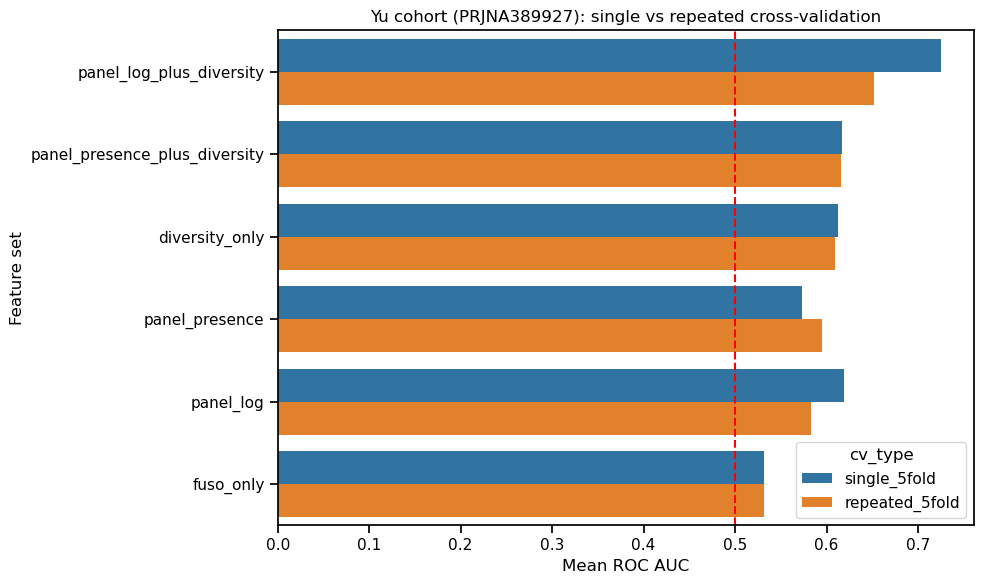

In [19]:
# Cell 18 — Compare single 5-fold vs repeated 5-fold CV

comparison_rows = []

for fs_name, cols in feature_sets.items():
    if len(cols) == 0:
        continue

    X = df[cols]
    y = df["y"]

    # Use the best model from the main repeated-CV table for this feature set
    best_model_for_fs = (
        results_df[results_df["feature_set"] == fs_name]
        .sort_values("auc_mean", ascending=False)
        .iloc[0]["model"]
    )
    model = models[best_model_for_fs]
    pipe = build_pipeline(model)

    single_scores = cross_val_score(pipe, X, y, cv=cv_single, scoring="roc_auc")
    repeated_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    comparison_rows.append({
        "feature_set": fs_name,
        "model": best_model_for_fs,
        "cv_type": "single_5fold",
        "auc_mean": single_scores.mean(),
        "auc_std": single_scores.std(),
    })

    comparison_rows.append({
        "feature_set": fs_name,
        "model": best_model_for_fs,
        "cv_type": "repeated_5fold",
        "auc_mean": repeated_scores.mean(),
        "auc_std": repeated_scores.std(),
    })

cv_comparison_df = pd.DataFrame(comparison_rows)
display(cv_comparison_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cv_comparison_df,
    x="auc_mean",
    y="feature_set",
    hue="cv_type",
    order=feature_order,
)
plt.axvline(0.5, linestyle="--", color="red")
plt.xlabel("Mean ROC AUC")
plt.ylabel("Feature set")
plt.title(f"{cohort_name}: single vs repeated cross-validation")
plt.tight_layout()
plt.show()

/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_rat

,cv_scheme,feature_set,model,auc_mean,auc_std
16,8fold_x10,panel_log_plus_diversity,logistic_l1,0.653500,0.177194
10,5fold_x10,panel_log_plus_diversity,logistic_l1,0.651875,0.126516
4,3fold_x10,panel_log_plus_diversity,logistic_l1,0.610158,0.090004
7,5fold_x10,diversity_only,logistic_l1,0.609688,0.130746
13,8fold_x10,diversity_only,logistic_l1,0.602500,0.189456
1,3fold_x10,diversity_only,logistic_l1,0.599084,0.091898
15,8fold_x10,panel_presence,logistic_l1,0.595000,0.169602
9,5fold_x10,panel_presence,logistic_l1,0.594844,0.107063
14,8fold_x10,panel_log,logistic_l1,0.594500,0.165981
17,8fold_x10,panel_presence_plus_diversity,logistic_l1,0.584000,0.167881


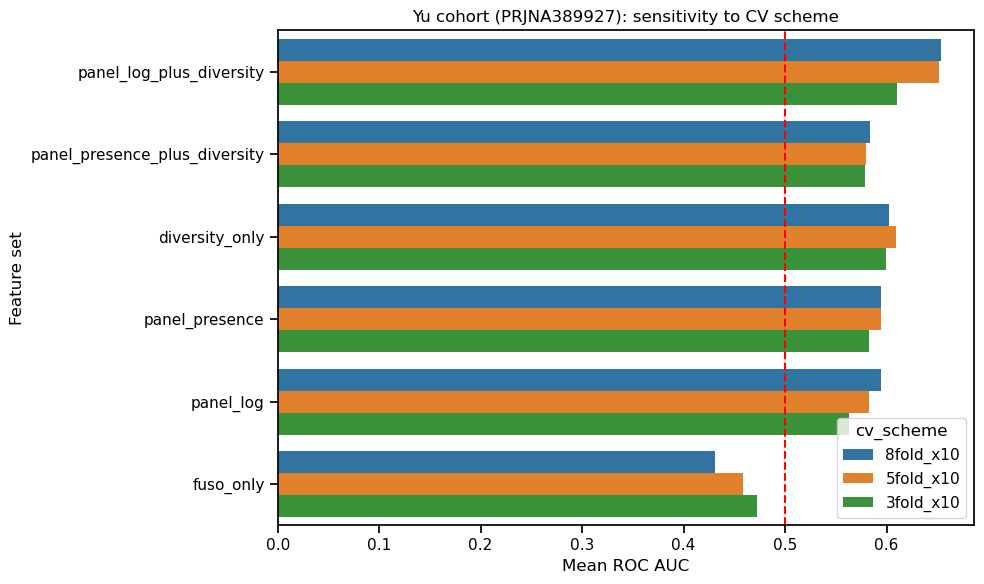

In [20]:
# Cell 19 — Optional sensitivity to CV scheme

cv_options = {
    "3fold_x10": RepeatedStratifiedKFold(n_splits=3, n_repeats=10, random_state=42),
    "5fold_x10": RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
    "8fold_x10": RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42),
}

cv_rows = []

for cv_name, cv_obj in cv_options.items():
    for fs_name, cols in feature_sets.items():
        if len(cols) == 0:
            continue

        X = df[cols]
        y = df["y"]

        # Keep sensitivity plot compact by using logistic_l1 only
        model_name = "logistic_l1"
        model = models[model_name]
        pipe = build_pipeline(model)

        scores = cross_val_score(pipe, X, y, cv=cv_obj, scoring="roc_auc")

        cv_rows.append({
            "cv_scheme": cv_name,
            "feature_set": fs_name,
            "model": model_name,
            "auc_mean": scores.mean(),
            "auc_std": scores.std(),
        })

cv_sensitivity_df = pd.DataFrame(cv_rows).sort_values("auc_mean", ascending=False)
display(cv_sensitivity_df.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cv_sensitivity_df,
    x="auc_mean",
    y="feature_set",
    hue="cv_scheme",
    order=feature_order,
)
plt.axvline(0.5, linestyle="--", color="red")
plt.xlabel("Mean ROC AUC")
plt.ylabel("Feature set")
plt.title(f"{cohort_name}: sensitivity to CV scheme")
plt.tight_layout()
plt.show()

In [21]:
# Cell 20 — Choose final model for detailed figures

best_row = results_df.iloc[0]

best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_features = feature_sets[best_feature_set]
best_model = models[best_model_name]

print("Best feature set:", best_feature_set)
print("Best model:", best_model_name)
print("Number of features:", len(best_features))
print("Repeated CV mean AUC:", best_row["auc_mean"])
print("Repeated CV AUC std:", best_row["auc_std"])

Best feature set: panel_log_plus_diversity
Best model: logistic_l1
Number of features: 38
Repeated CV mean AUC: 0.651875
Repeated CV AUC std: 0.12651580928879996


/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_rat

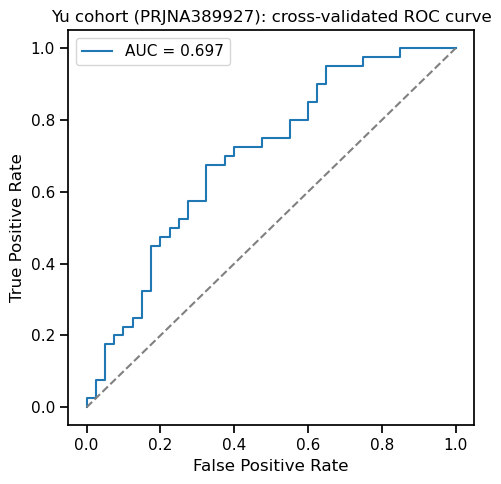

In [22]:
# Cell 21 — Cross-validated ROC curve for final model

X_best = df[best_features]
y = df["y"]
best_pipe = build_pipeline(best_model)

# Use a single 5-fold split for a single ROC visualization.
# The repeated-CV table remains the main performance estimate.
y_proba = cross_val_predict(
    best_pipe,
    X_best,
    y,
    cv=cv_single,
    method="predict_proba",
)[:, 1]

roc_auc = roc_auc_score(y, y_proba)
fpr, tpr, _ = roc_curve(y, y_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{cohort_name}: cross-validated ROC curve")
plt.legend()
plt.tight_layout()
plt.show()

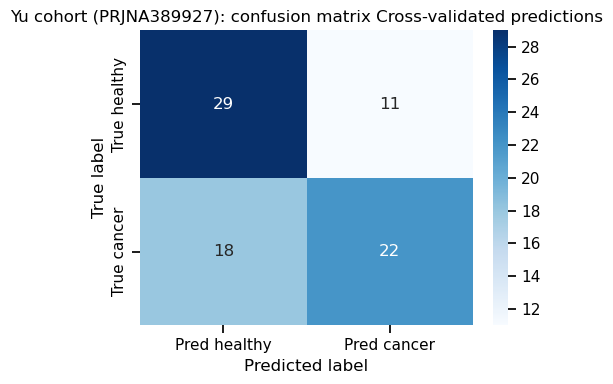

              precision    recall  f1-score   support

     healthy       0.62      0.72      0.67        40
      cancer       0.67      0.55      0.60        40

    accuracy                           0.64        80
   macro avg       0.64      0.64      0.63        80
weighted avg       0.64      0.64      0.63        80



In [23]:
# Cell 22 — Cross-validated confusion matrix for final model

y_pred = (y_proba >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred healthy", "Pred cancer"],
    yticklabels=["True healthy", "True cancer"],
)
plt.title(f"{cohort_name}: confusion matrix Cross-validated predictions")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred, target_names=["healthy", "cancer"]))

/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/jackpapciak/miniconda3/envs/fuso/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,feature,coefficient,abs_coefficient,direction
24,panel_Collinsella_log10,1.956299,1.956299,cancer-associated
36,number_of_detected_species,-1.703777,1.703777,healthy-associated
11,panel_Parabacteroides_log10,1.550541,1.550541,cancer-associated
19,panel_Kingevirus_log10,-1.485459,1.485459,healthy-associated
12,panel_Bacteroides_log10,-1.444353,1.444353,healthy-associated
8,panel_Bifidobacterium_longum_log10,-1.422828,1.422828,healthy-associated
37,total_bacterial_abundance,-0.872718,0.872718,healthy-associated
35,Shannon_diversity,0.845882,0.845882,cancer-associated
17,panel_Mediterraneibacter_log10,0.826020,0.826020,cancer-associated
34,panel_Canhaevirus_log10,-0.673465,0.673465,healthy-associated


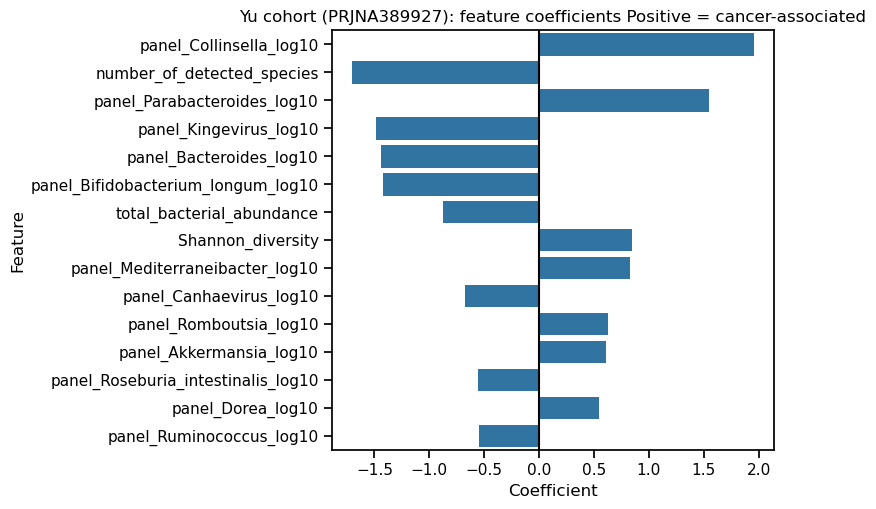

In [24]:
# Cell 23 — Descriptive feature importance for final model

# Note: this fits the final model on all samples and is descriptive, not cross-validated inference.

best_pipe.fit(X_best, y)

if isinstance(best_model, LogisticRegression):
    coefs = best_pipe.named_steps["model"].coef_[0]

    importance_df = pd.DataFrame({
        "feature": X_best.columns,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
        "direction": np.where(coefs > 0, "cancer-associated", "healthy-associated"),
    }).sort_values("abs_coefficient", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(8, max(4, 0.35 * min(15, len(importance_df)))))
    sns.barplot(
        data=importance_df.head(15),
        x="coefficient",
        y="feature",
        orient="h",
    )
    plt.axvline(0, color="black")
    plt.title(f"{cohort_name}: feature coefficients Positive = cancer-associated")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    perm = permutation_importance(
        best_pipe,
        X_best,
        y,
        n_repeats=50,
        random_state=42,
        scoring="roc_auc",
    )

    importance_df = pd.DataFrame({
        "feature": X_best.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(8, max(4, 0.35 * min(15, len(importance_df)))))
    sns.barplot(
        data=importance_df.head(15),
        x="importance_mean",
        y="feature",
        orient="h",
    )
    plt.title(f"{cohort_name}: permutation importance")
    plt.xlabel("Mean decrease in ROC AUC")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

,feature,importance_mean,importance_std
36,number_of_detected_species,0.207525,0.040627
24,panel_Collinsella_log10,0.179513,0.032908
11,panel_Parabacteroides_log10,0.175900,0.030400
12,panel_Bacteroides_log10,0.167288,0.032256
19,panel_Kingevirus_log10,0.157300,0.029361
8,panel_Bifidobacterium_longum_log10,0.152088,0.024848
37,total_bacterial_abundance,0.074525,0.017927
17,panel_Mediterraneibacter_log10,0.059925,0.013604
35,Shannon_diversity,0.059600,0.017781
34,panel_Canhaevirus_log10,0.046050,0.015163


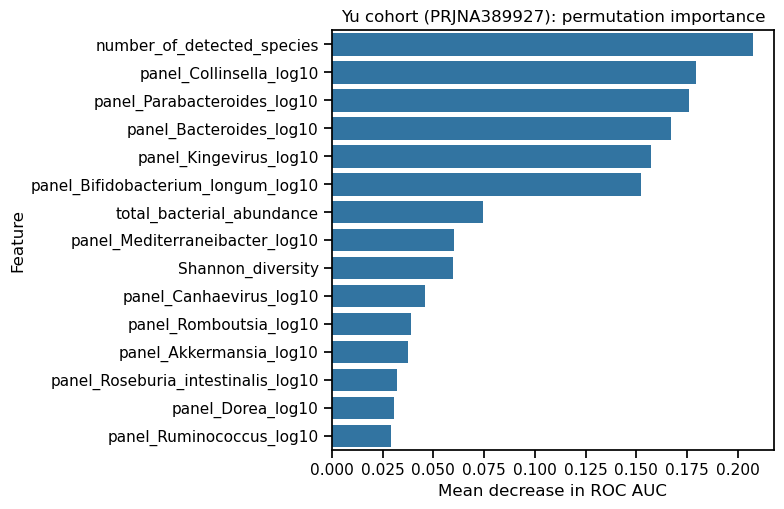

In [25]:
# Cell 24 — Permutation importance for best model, regardless of model type

# This gives a model-agnostic feature importance view.
# Note: descriptive; computed after fitting on all samples.

perm = permutation_importance(
    best_pipe,
    X_best,
    y,
    n_repeats=50,
    random_state=42,
    scoring="roc_auc",
)

perm_df = pd.DataFrame({
    "feature": X_best.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

plt.figure(figsize=(8, max(4, 0.35 * min(15, len(perm_df)))))
sns.barplot(
    data=perm_df.head(15),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title(f"{cohort_name}: permutation importance")
plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

,feature,feature_source,healthy_mean,cancer_mean,mean_diff,abs_diff,p_value,feature_type,importance_mean
25,panel_Collinsella_log10,log10_abundance,-3.454191,-3.384464,0.069727,0.069727,0.907861,log10_abundance,0.179513
1,panel_Parabacteroides_log10,log10_abundance,-1.953547,-1.576869,0.376678,0.376678,0.115654,log10_abundance,0.175900
2,panel_Bacteroides_log10,log10_abundance,-1.446335,-1.701224,-0.254889,0.254889,0.053097,log10_abundance,0.167288
0,panel_Kingevirus_log10,log10_abundance,-4.212816,-5.037318,-0.824503,0.824503,0.028084,log10_abundance,0.157300
8,panel_Bifidobacterium_longum_log10,log10_abundance,-3.094575,-3.291719,-0.197144,0.197144,0.657940,log10_abundance,0.152088
32,panel_Mediterraneibacter_log10,log10_abundance,-2.237503,-2.206278,0.031225,0.031225,0.787596,log10_abundance,0.059925
26,panel_Canhaevirus_log10,log10_abundance,-4.386986,-4.318044,0.068942,0.068942,0.831641,log10_abundance,0.046050
4,panel_Romboutsia_log10,log10_abundance,-2.903157,-3.115982,-0.212825,0.212825,0.291983,log10_abundance,0.039075
31,panel_Akkermansia_log10,log10_abundance,-3.145060,-3.194543,-0.049483,0.049483,0.862444,log10_abundance,0.037225
5,panel_Roseburia_intestinalis_log10,log10_abundance,-2.672630,-2.884266,-0.211636,0.211636,0.413382,log10_abundance,0.031800


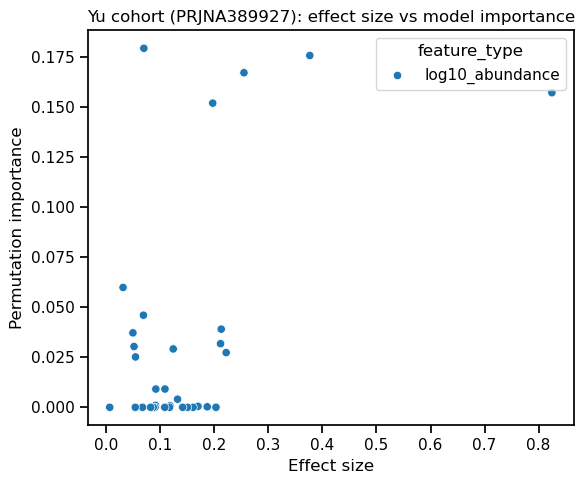

In [26]:
# Cell 25 — Combine effect size with permutation importance

# This helps distinguish features that differ between groups from features the model actually uses.

combined_effects = []
if not presence_effects.empty:
    tmp = presence_effects.copy()
    tmp["feature_type"] = "presence"
    combined_effects.append(tmp)
if not log_effects.empty:
    tmp = log_effects.copy()
    tmp["feature_type"] = "log10_abundance"
    combined_effects.append(tmp)

if combined_effects:
    effect_df = pd.concat(combined_effects, ignore_index=True)

    effect_importance_df = effect_df.merge(
        perm_df[["feature", "importance_mean"]],
        on="feature",
        how="inner",
    )

    display(effect_importance_df.sort_values("importance_mean", ascending=False).head(20))

    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=effect_importance_df,
        x="abs_diff",
        y="importance_mean",
        hue="feature_type",
    )
    plt.xlabel("Effect size")
    plt.ylabel("Permutation importance")
    plt.title(f"{cohort_name}: effect size vs model importance")
    plt.tight_layout()
    plt.show()
else:
    print("No effect-size dataframe available to combine with permutation importance.")

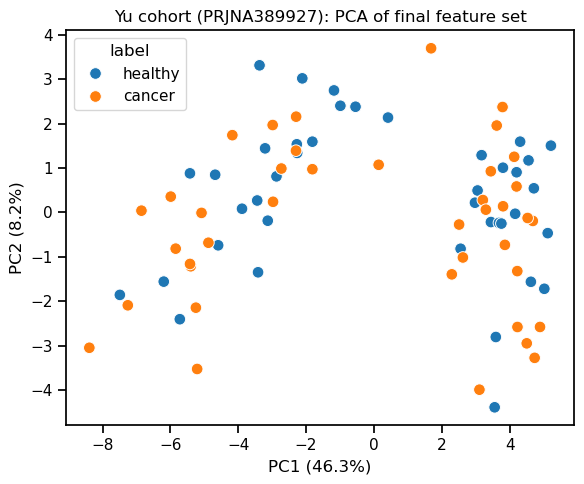

In [27]:
# Cell 26 — PCA visualization of selected feature set

X_plot = X_best.copy()

X_imp = SimpleImputer(strategy="constant", fill_value=0).fit_transform(X_plot)

if X_plot.shape[1] > 1:
    X_scaled = StandardScaler().fit_transform(X_imp)

    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        "label": df["label"].values,
        "sample_id": df["sample_id"].values,
    })

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label", s=70)
    plt.title(f"{cohort_name}: PCA of final feature set")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.tight_layout()
    plt.show()
else:
    print("PCA skipped: final feature set has fewer than 2 features.")

In [28]:
# Cell 27 — Save outputs

from pathlib import Path
Path(out_dir).mkdir(parents=True, exist_ok=True)

results_df.to_csv(f"{out_dir}/{cohort_name}_model_comparison_results.csv", index=False)
cv_comparison_df.to_csv(f"{out_dir}/{cohort_name}_cv_comparison_results.csv", index=False)
cv_sensitivity_df.to_csv(f"{out_dir}/{cohort_name}_cv_sensitivity_results.csv", index=False)
perm_df.to_csv(f"{out_dir}/{cohort_name}_permutation_importance.csv", index=False)

if "importance_df" in globals():
    importance_df.to_csv(f"{out_dir}/{cohort_name}_feature_importance.csv", index=False)

if not presence_effects.empty:
    presence_effects.to_csv(f"{out_dir}/{cohort_name}_presence_effect_sizes.csv", index=False)
if not log_effects.empty:
    log_effects.to_csv(f"{out_dir}/{cohort_name}_log_effect_sizes.csv", index=False)

print("Saved results to:", out_dir)

Saved results to: /Users/jackpapciak/Columbia/Computational_Genomics/fuso-biomarker/results/Yu_PRJNA389927
